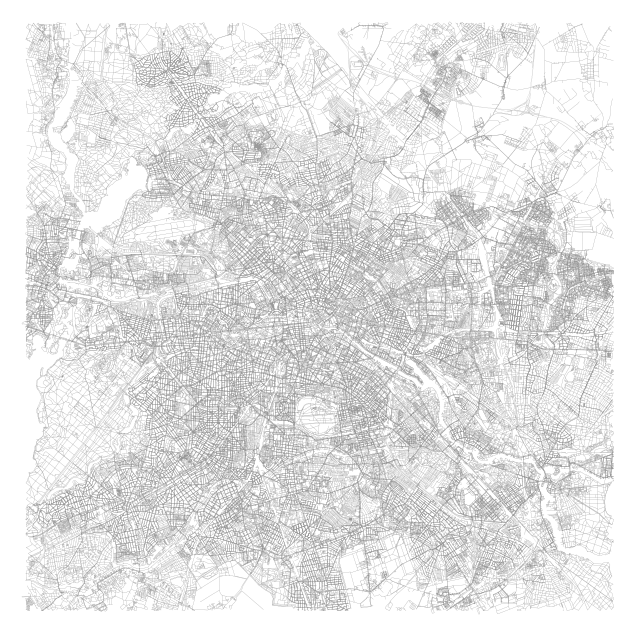

In [14]:
import osmnx as osm

berlin_rn = osm.graph_from_point((52.520008,13.404954), dist = 15000)

_,axis1 = osm.plot_graph(berlin_rn, node_size=0,edge_linewidth=0.09, bgcolor='white', show=True)


In [15]:
# parse the frequent maximal polylines
import os
import utm
class Trajectory:
    def __init__(self):
        self.points = []
        self.ids = []
        self.beginnings = {}
    
    def push_back(self, coords, id):
        if len(self.points)> 0:
            
            if id != self.ids[-1]:
                self.beginnings[id] = len(self.points) - 1
    
        else:
            self.beginnings[id] = 0
        
        self.points.append(coords)
        self.ids.append(id)
        
    
    def get_x_coord_at(self,idx):

        return self.points[idx][0]
    
    def get_y_coord_at(self,idx):

        return self.points[idx][1]
    
    # return list of tuples
    def get_pathlet_points(self, beginning, end, id)-> list:

        start_offset = self.beginnings[id] + beginning
        end_offset = self.beginnings[id] + end 

        l = []
        
        for i in range(start_offset, end_offset + 1):
            l.append(self.points[i])

        return l

def get_polyline_string(l) -> str:

    s = "MULTILINESTRING(("

    for i in range(0, len(l)):
        s += f"{l[i][1]} {l[i][0]}"

        if i < len(l) - 1:
            s+= ","
    
    s += "))"

    return s


def load_trajectory_from_file(file)-> Trajectory:
    
    t = Trajectory()
    assert os.path.exists(file)
    if os.path.exists(file):

        with open(file, 'r') as handle:
            for line in handle:
                point_line = line.split(" ")

                id = int(point_line[-1])
                #print(id)

                coords = tuple(map(float, (point_line[:-1])))

                coords = utm.to_latlon(coords[0], coords[1],33,'W')
                #print(coords)
                t.push_back(coords, id)

    return t

def generate_polyline_columns(t, pathlet_file):
    return



In [ ]:
import pandas as pd 
import geopandas as gpd
from shapely import wkt 

pathlet_number = 10
#axis1 = osm.plot_graph(berlin_rn, node_size=0,edge_linewidth=0.09, bgcolor='white', show=True)
berlin_gdf = osm.convert.graph_to_gdfs(berlin_rn) #set CRS
#ax1 = berlin_gdf[0].plot(marker='o', markersize=0.01, color='lightgrey', zorder=2)
ax1 = berlin_gdf[1].plot(edgecolor='lightgray', zorder=1)
t = load_trajectory_from_file("./berlin/merged.txt")

#print(t.beginnings)
pathlet_beginning = 0
pathlet_end = 5
pathlet_mother = 3
print(t.beginnings)
l = t.get_pathlet_points(pathlet_beginning,pathlet_end, pathlet_mother)
print(get_polyline_string(l))
# create dataframe of the 2 polygons
d = {'col1': range(0, 1), 'wkt': [get_polyline_string(l)]}
df = pd.DataFrame( data=d )

# make geo-dataframe from it
geometry = [wkt.loads(pgon) for pgon in df.wkt]
gdf2 = gpd.GeoDataFrame(df, \
                   crs={'init': 'epsg:4326'}, \
                   geometry=geometry)

# plot it as red polygons
gdf2.plot(ax=ax1, color='red', zorder=5)


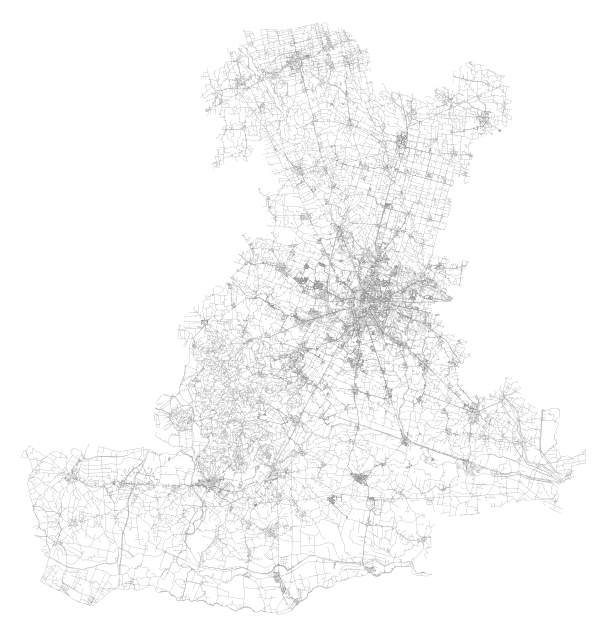

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [2]:
osm.plot_graph(padova_rn, node_size=0, edge_linewidth=0.09, bgcolor='white', show=True)